In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
resumeDF = pd.read_csv("UpdatedResumeDataSet.csv")


In [3]:
resumeDF.value_counts()

Category            Resume                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                              

In [4]:
resumeDF['Category'].value_counts()

Category
Java Developer               84
Testing                      70
DevOps Engineer              55
Python Developer             48
Web Designing                45
HR                           44
Hadoop                       42
Data Science                 40
Mechanical Engineer          40
Sales                        40
Operations Manager           40
ETL Developer                40
Blockchain                   40
Arts                         36
Database                     33
Health and fitness           30
Electrical Engineering       30
PMO                          30
Business Analyst             28
DotNet Developer             28
Automation Testing           26
Network Security Engineer    25
Civil Engineer               24
SAP Developer                24
Advocate                     20
Name: count, dtype: int64

In [5]:
resumeDF["Category"].unique()

<ArrowStringArray>
[             'Data Science',                        'HR',
                  'Advocate',                      'Arts',
             'Web Designing',       'Mechanical Engineer',
                     'Sales',        'Health and fitness',
            'Civil Engineer',            'Java Developer',
          'Business Analyst',             'SAP Developer',
        'Automation Testing',    'Electrical Engineering',
        'Operations Manager',          'Python Developer',
           'DevOps Engineer', 'Network Security Engineer',
                       'PMO',                  'Database',
                    'Hadoop',             'ETL Developer',
          'DotNet Developer',                'Blockchain',
                   'Testing']
Length: 25, dtype: str

In [6]:
resumeDF.info()

<class 'pandas.DataFrame'>
RangeIndex: 962 entries, 0 to 961
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Category  962 non-null    str  
 1   Resume    962 non-null    str  
dtypes: str(2)
memory usage: 2.9 MB


In [7]:
resumeDF.dtypes

Category    str
Resume      str
dtype: object

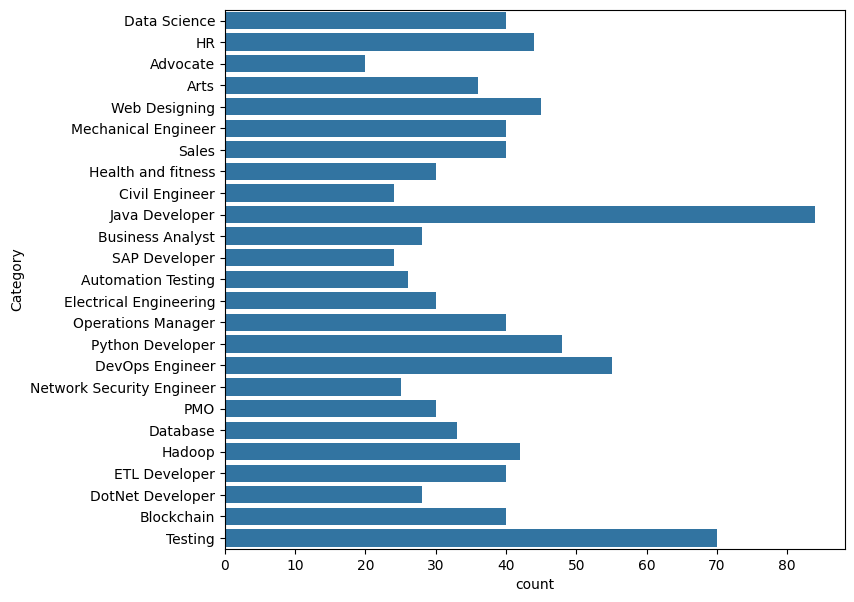

In [8]:
plt.figure(figsize=(8,7))
sns.countplot(resumeDF["Category"])
plt.show()

In [9]:
import re
from bs4 import BeautifulSoup

In [10]:
# Function for removing HTML Tags
# Using Beautiful Soup
def htmlText(text):
    soup = BeautifulSoup(text,"lxml")
    return soup.get_text()

In [11]:
resumeDF['htmlTagsRemoved'] = resumeDF['Resume'].apply(htmlText)

In [12]:
resumeDF['htmlTagsRemoved'].head()

0    Skills * Programming Languages: Python (pandas...
1    Education Details \nMay 2013 to May 2017 B.E  ...
2    Areas of Interest Deep Learning, Control Syste...
3    Skills â¢ R â¢ Python â¢ SAP HANA â¢ Table...
4    Education Details \n MCA   YMCAUST,  Faridabad...
Name: htmlTagsRemoved, dtype: str

In [13]:
# Function for regularization of the text
def regData(text):
    regularLinkText = re.sub('http\S+\s',' ',text)
    regularHashText = re.sub('@\S+',' ',regularLinkText)
    regularMentionText = re.sub('#\S+',' ',regularHashText)
    regularSpecialText =  re.sub('[%s]' % re.escape("""!"#$%&'()*+,-./:;<=>?@[\]^_`{|}~"""), ' ', regularMentionText)
    regularDiffText =  re.sub(r'[^\x00-\x7f]', ' ', regularSpecialText) 
    regularSpaceText = re.sub(r'\s+',' ',regularDiffText)
    return regularSpaceText


In [14]:
regData("my #### $ #  #hellowrold webiste this working http://heloword and access it @gmail.com")

'my webiste this working and access it '

In [15]:
resumeDF["htmlTagsRemoved"] = resumeDF["htmlTagsRemoved"].apply(lambda x: regData(x))

In [16]:
resumeDF["htmlTagsRemoved"]

0      Skills Programming Languages Python pandas num...
1      Education Details May 2013 to May 2017 B E UIT...
2      Areas of Interest Deep Learning Control System...
3      Skills R Python SAP HANA Tableau SAP HANA SQL ...
4      Education Details MCA YMCAUST Faridabad Haryan...
                             ...                        
957    Computer Skills Proficient in MS office Word B...
958     Willingness to accept the challenges Positive...
959    PERSONAL SKILLS Quick learner Eagerness to lea...
960    COMPUTER SKILLS SOFTWARE KNOWLEDGE MS Power Po...
961    Skill Set OS Windows XP 7 8 8 1 10 Database MY...
Name: htmlTagsRemoved, Length: 962, dtype: str

In [17]:
from sklearn.preprocessing import LabelEncoder
encoding = LabelEncoder()

In [18]:
encoding.fit(resumeDF["Category"])
resumeDF["labelCategory"] = encoding.transform(resumeDF["Category"])

In [19]:
resumeDF[["Category","labelCategory"]]

,Category,labelCategory
0,Data Science,6
1,Data Science,6
2,Data Science,6
3,Data Science,6
4,Data Science,6
...,...,...
957,Testing,23
958,Testing,23
959,Testing,23
960,Testing,23


In [23]:
from nltk.stem import PorterStemmer
from nltk.corpus import stopwords 

In [25]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


True

In [26]:
STOPWORDS = set(stopwords.words('english'))

In [27]:
corpus = []
stemmer = PorterStemmer()
for i in range(0, resumeDF.shape[0]):
  review = re.sub('[^a-zA-Z]', ' ', resumeDF.iloc[i]['htmlTagsRemoved'])
  review = review.lower().split()
  review = [stemmer.stem(word) for word in review if not word in STOPWORDS]
  review = ' '.join(review)
  corpus.append(review)

In [28]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [29]:
tfIDF = TfidfVectorizer()

In [30]:
X = corpus
y = resumeDF["labelCategory"]

In [31]:
X_tfidf = tfIDF.fit_transform(X).toarray()

In [32]:
X_tfidf.shape , y.shape   

((962, 5162), (962,))

In [33]:
from sklearn.model_selection import train_test_split
X_train , X_test , y_train , y_test = train_test_split(X_tfidf,y,test_size=0.2,random_state=42)
X_train.shape , X_test.shape , y_train.shape , y_test.shape

((769, 5162), (193, 5162), (769,), (193,))

In [35]:
from imblearn.over_sampling import SMOTE

In [36]:
smote = SMOTE(random_state=42)
X_train_SMOTE , y_train_SMOTE = smote.fit_resample(X_train, y_train)
X_train_SMOTE.shape , y_train_SMOTE.shape

((1725, 5162), (1725,))

In [38]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression


# Initialize the logistic regression model
logREG = LogisticRegression(max_iter=1000,solver='lbfgs')

# Perform cross-validation with 5 folds
cv_scores = cross_val_score(logREG, X_train_SMOTE, y_train_SMOTE, cv=5)

# Print the cross-validation scores
print("Cross-Validation Scores:", cv_scores)

Cross-Validation Scores: [0.99710145 0.99710145 1.         1.         1.        ]


In [39]:
logREG = LogisticRegression()
logREG.fit(X_train_SMOTE,y_train_SMOTE)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [40]:
from sklearn.metrics import confusion_matrix , classification_report , accuracy_score
from sklearn.metrics import ConfusionMatrixDisplay

In [41]:
y_logREG_pred = logREG.predict(X_test)

In [42]:
print(accuracy_score(y_test,y_logREG_pred))

0.9948186528497409


In [43]:
#Confusion Matrix
cm = confusion_matrix(y_test, y_logREG_pred)

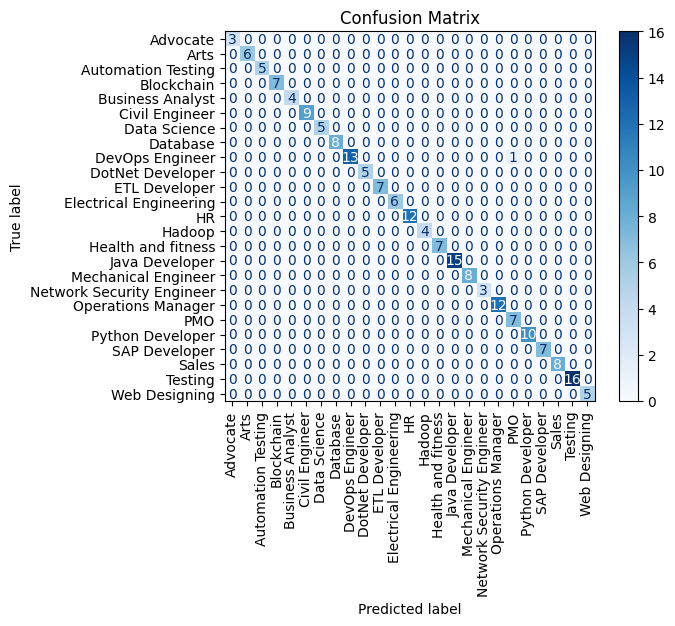

In [44]:
cm_display = ConfusionMatrixDisplay(confusion_matrix=cm,
                                    display_labels=encoding.classes_)
cm_display.plot(cmap=plt.cm.Blues) 
plt.title('Confusion Matrix') 
plt.xticks(rotation=90)
plt.show()

In [45]:
print("\n Classification report for classifier %s:\n%s\n" % (logREG, classification_report(y_test, y_logREG_pred)))


 Classification report for classifier LogisticRegression():
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         3
           1       1.00      1.00      1.00         6
           2       1.00      1.00      1.00         5
           3       1.00      1.00      1.00         7
           4       1.00      1.00      1.00         4
           5       1.00      1.00      1.00         9
           6       1.00      1.00      1.00         5
           7       1.00      1.00      1.00         8
           8       1.00      0.93      0.96        14
           9       1.00      1.00      1.00         5
          10       1.00      1.00      1.00         7
          11       1.00      1.00      1.00         6
          12       1.00      1.00      1.00        12
          13       1.00      1.00      1.00         4
          14       1.00      1.00      1.00         7
          15       1.00      1.00      1.00        15
          16       1

In [46]:
import pickle
pickle.dump(tfIDF,open('tfIDF.pkl','wb'))
pickle.dump(logREG, open('clfLR.pkl', 'wb'))
pickle.dump(encoding, open("encoderLabel.pkl",'wb'))

In [47]:
def pred(input_resume):
  
  corpus = []
  stemmer = PorterStemmer()
  review = re.sub('[^a-zA-Z]', ' ', input_resume)
  lowerReview = review.lower().split()
  review = [stemmer.stem(word) for word in lowerReview if not word in STOPWORDS]
  review = ' '.join(review)
  corpus.append(review)
  
  vectorized_text = tfIDF.transform(corpus)

#  threshold = 0.078785
  threshold =  0.076788

  predicted_category = logREG.predict_proba(vectorized_text)
  max_proba = max(predicted_category[0]) 

  if input_resume.strip() == "":
    print("Error: Input is empty.")
  elif max_proba < threshold and len(input_resume) < 200 :
    print("Error: Low confidence in prediction. The input might be invalid with the following probability")
    return max_proba
  elif max_proba < threshold:
     return max_proba
  else:
      vectorized_text = vectorized_text.toarray()
      predicted_category = logREG.predict(vectorized_text)
      predicted_category_name = encoding.inverse_transform(predicted_category)
      print("Prediction:", predicted_category_name)
      return predicted_category_name[0] , max_proba
  

In [48]:
myresume1 = """ 

Job description
As part of our global expansion efforts, Onboard is actively scaling operations to over 20 countries and seeking to recruit merchants and liquidity providers worldwide. To support this mission, we are looking for Merchant Relations Advocates to serve as our first line of operational support in launch countries.
These advocates will play a crucial role in identifying ideal merchant candidates, maintaining strong relationships with them, and bridging communication gaps professionally and courteously.
The ideal Merchant Relations Advocate will be a member of the Onboard City Club, with deep knowledge of and influence within their local city or country.
Duties and Responsibilities
Identify and onboard potential merchants, such as high-value transaction (HVT) users or existing merchants from other platforms.
Serve as a liaison between local merchants and Onboard, ensuring effective communication.
Clearly communicate Key Performance Indicators (KPIs) related to Guaranteed Earnings to merchants and co-monitor their performance.
Provide support for merchant customer experience (CX) needs, helping to resolve issues and addressing concerns in a timely manner.
Qualifications and Requirements
Solid understanding of the crypto and digital asset industry within your city or country.
Prior Merchant experience on any p2p platform is preferred
Exceptional verbal and written communication skills in the local language.
Excellent customer service and interpersonal skills.
Strong organisational and coordination abilities.
Ability to collaborate effectively with a diverse and global team.

Benefits to you
Opportunity to do meaningful work
Part-time work with a fast-paced team and opportunity to join Onboard Global on Full full-time basis
Weekly internet allowance
Role: Operations - Other
Industry Type: IT Services & Consulting
Department: Customer Success, Service & Operations
Employment Type: Full Time, Permanent
Role Category: Operations
Education
UG: Any Graduate
PG: Any Postgraduate
Key Skills
operational supportInterpersonal skillsRelationshipAdvocateCustomer serviceCustomer experienceMonitoringRecruitment




"""

In [49]:
pred(myresume1)

Prediction: ['Advocate']


('Advocate', np.float64(0.07777138959652086))

In [50]:
import pdfplumber

with pdfplumber.open(r"Parsing\Resume\Anushka.pdf") as pdf:
    text = "\n".join(page.extract_text() for page in pdf.pages)

print(text)

Anushka Suvarna
Student
(cid:131) 8149498857 # concept.anushka@gmail.com
(cid:239) linkedin.com/in/anushkasuvarna
About Me
Third-year Computer Engineering student with experience in developing full-stack web applications. Comfortable working
across frontend and backend layers, with project experience in API design, authentication, database systems, and AI-driven
applications.
Education
Sardar Patel Institute of Technology Aug 2023 – Present
B.Tech in Computer Engineering — CGPA: 9.44
– Pursuing a Minor in Management from S.P. Jain Institute of Management & Research (SPJIMR), Mumbai.
Indian Institute of Technology Madras Jun 2023 – Present
BS in Data Science & Business Applications
Muljibhai Mehta International School Aug 2021 – Mar 2023
Class XII (Science) — 96%
Sheth Vidya Mandir English High School Apr 2008 – Mar 2021
Class X (SSC) — 97.2%
Projects
SubmitOK – AI-Based Academic Evaluation System | Vue.js, FastAPI, Firebase, Cloudinary Dec 2025 – Jan 2026
– Built an AI-powered academic

In [51]:
pred(text)

Prediction: ['Data Science']


('Data Science', np.float64(0.10483188864498239))